In [1]:
import importlib
import gymnasium as gym

import env.afm_env
importlib.reload(env.afm_env)
from env.afm_env import AfmEnvironment

from stable_baselines3 import SAC
import numpy as np

env = AfmEnvironment(
    data_file_path="environments/pt_111_small_rows_missing.npz",
    num_historic_data=40,
    num_actions=1,
)

env.afm_images = np.rot90(env.afm_images, k=1, axes=(0, 1))
env.min_image = np.rot90(env.min_image, k=1, axes=(0, 1))
env.optimal_height = np.rot90(env.optimal_height, k=1, axes=(0, 1))

# 3. Update the limits to match the new rotated shapes
env._x_lim = env.afm_images.shape[0]
env._y_lim = env.afm_images.shape[1]

# 4. Update the normalization bounds for the new X and Y limits
# Note: 'df' and 'dz' bounds don't need changing since the min/max values remain identical
env.norm_bounds['x'] = (0.0, float(env._x_lim - 1))
env.norm_bounds['y'] = (0.0, float(env._y_lim - 1))

# 5. Call reset() so internal state variables (like `self.generated_image`)
# are initialized with the newly rotated dimensions
obs, info = env.reset()

# model = SAC.load("train_results/sac_afm_model_arch256x256_hist40_df10.0_dz10.0_2026-02-23_00-06-02/models/sac_afm_model_arch256x256_hist40_df10.0_dz10.0_2026-02-23_00-06-02_4440000_steps.zip")
model = SAC.load("train_results/sac_afm_model_arch512x512_hist40_df10.0_dz10.0_2026-02-23_00-07-21/models/sac_afm_model_arch512x512_hist40_df10.0_dz10.0_2026-02-23_00-07-21_5640000_steps.zip")

 PACKAGE_PATH =  /home/henry/miniforge3/envs/IProject/lib/python3.11/site-packages/ppafm
 CPP_PATH     =  /home/henry/miniforge3/envs/IProject/lib/python3.11/site-packages/ppafm/cpp


In [2]:
import pickle
import os
import datetime
import numpy as np

EVAL_BASE_DIR = "eval_results"
start_and_finish = {}
episodes = []

for ep in range(1):
    print(ep)
    obs_arr, rewards_arr, info_arr, action_arr = [], [], [], []
    obs, info = env.reset()
    obs_arr.append(obs)
    info_arr.append(info)

    for i in range(201*201):
        action, _states = model.predict(obs)
        action_arr.append(action[0])
        obs, rewards, terminated, truncated, info = env.step(action)

        obs_arr.append(obs)
        rewards_arr.append(rewards)
        info_arr.append(info)

        if i%1000 == 0:
            print(" ", i)
        if terminated:
            break

    ep_dict = {
        "observations": obs_arr,
        "rewards": np.array(rewards_arr),
        "info": info_arr,
        "actions": np.array(action_arr),
        "episode_length": len(rewards_arr),
        "terminated_early": len(rewards_arr) < 201*201,
    }
    episodes.append(ep_dict)

EVAL_DIR = os.path.join(EVAL_BASE_DIR, datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S"))
os.makedirs(EVAL_DIR, exist_ok=True)
with open(os.path.join(EVAL_DIR, "results.pkl"), "wb") as f:
    pickle.dump(episodes, f)
    model.save(os.path.join(EVAL_DIR, "model"))

0
  0
  1000
  2000
  3000
  4000
  5000
  6000
  7000
  8000
  9000
  10000
  11000
  12000
  13000
  14000
  15000
  16000
  17000
  18000
  19000
  20000
  21000
  22000
  23000
  24000
  25000
  26000
  27000
  28000
  29000
  30000
  31000
  32000
  33000
  34000
  35000
  36000
  37000
  38000
  39000
  40000


Average reward (full episode): nan
Average reward (early termination): 9.486843681148162


/home/henry/miniforge3/envs/IProject/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/henry/miniforge3/envs/IProject/lib/python3.11/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


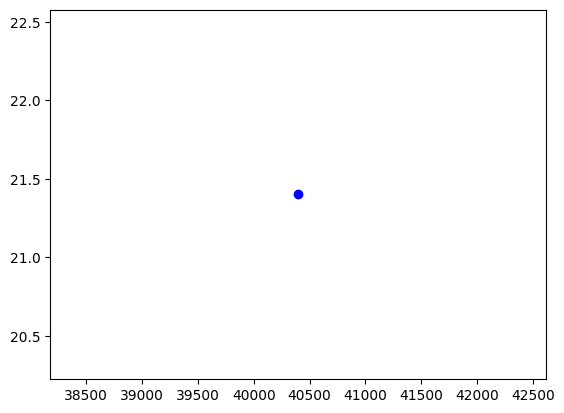

In [3]:
import matplotlib.pyplot as plt
avg_reward_full = np.mean([np.mean(ep["rewards"]) for ep in episodes if not ep["terminated_early"]])
avg_reward_early = np.mean([np.mean(ep["rewards"]) for ep in episodes if ep["terminated_early"]])

print(f"Average reward (full episode): {avg_reward_full}")
print(f"Average reward (early termination): {avg_reward_early}")

for ep in episodes:
    ep_len = len(ep["observations"])
    if ep_len < 201*201:
        plt.scatter(ep_len, ep["info"][0]["z"], c="red")
    else:
        plt.scatter(ep_len, ep["info"][0]["z"], c="blue")

plt.show()

In [4]:
def evaluate_run(episode, ma_height_len=100, ma_action_len=100, ma_reward_len=100):
    info = episode["info"]
    observations = episode["observations"]
    actions = episode["actions"]
    rewards = episode["rewards"]

    plt.rcParams["figure.figsize"] = (12, 10)
    plt.imshow(info[-1]["generated_image"].T)
    plt.colorbar()
    plt.title("Captured image")
    plt.show()

    height_img = np.zeros(201 * 201)
    height_img[:] = np.nan
    for counter, o, i in zip(range(201*201), observations, info):
        height_img[counter] = i["z"] + o["dz"][0]
    height_values = height_img.copy()
    height_img = height_img.reshape((201, 201))
    height_img[1::2] = height_img[1::2, ::-1]
    plt.imshow(height_img)
    plt.title("Height of tip")
    plt.colorbar()
    plt.show()

    plt.rcParams["figure.figsize"] = (20, 10)
    moving_avg = np.convolve(np.array(height_values).flatten(), np.ones(ma_height_len)/ma_height_len, mode='valid')
    plt.plot(moving_avg)
    plt.title(f"Moving average ({ma_height_len}) of height")
    plt.show()

    plt.rcParams["figure.figsize"] = (20, 10)
    moving_avg = np.convolve(np.array(actions).flatten(), np.ones(ma_action_len)/ma_action_len, mode='valid')
    plt.plot(moving_avg)
    plt.title(f"Moving average ({ma_action_len}) of actions")
    plt.show()

    plt.rcParams["figure.figsize"] = (20, 10)
    moving_avg = np.convolve(np.array(rewards).flatten(), np.ones(ma_reward_len)/ma_reward_len, mode='valid')
    plt.plot(moving_avg)
    plt.title(f"Moving average ({ma_reward_len}) of rewards (AVG={np.mean(rewards):.2f}, STD={np.std(rewards):.2f}, TOTAL={np.sum(rewards):.2f})")


In [5]:
max_len = 0
max_id = 0
for i, ep in enumerate(episodes):
    if ep["episode_length"] > max_len:
        max_len = ep["episode_length"]
        max_id = i

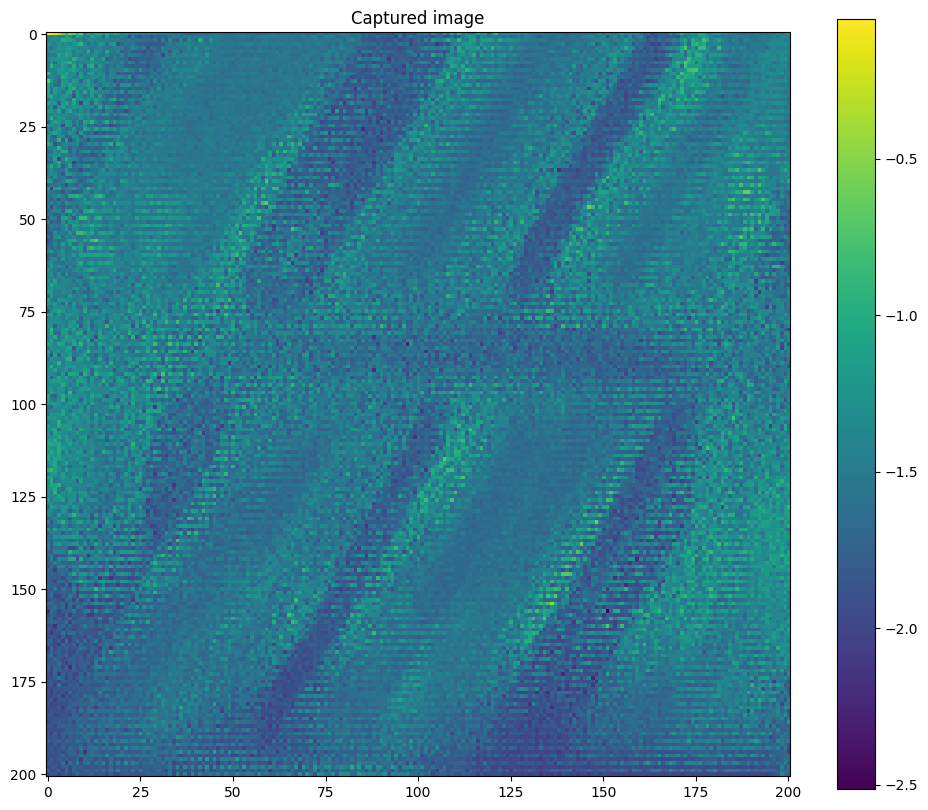

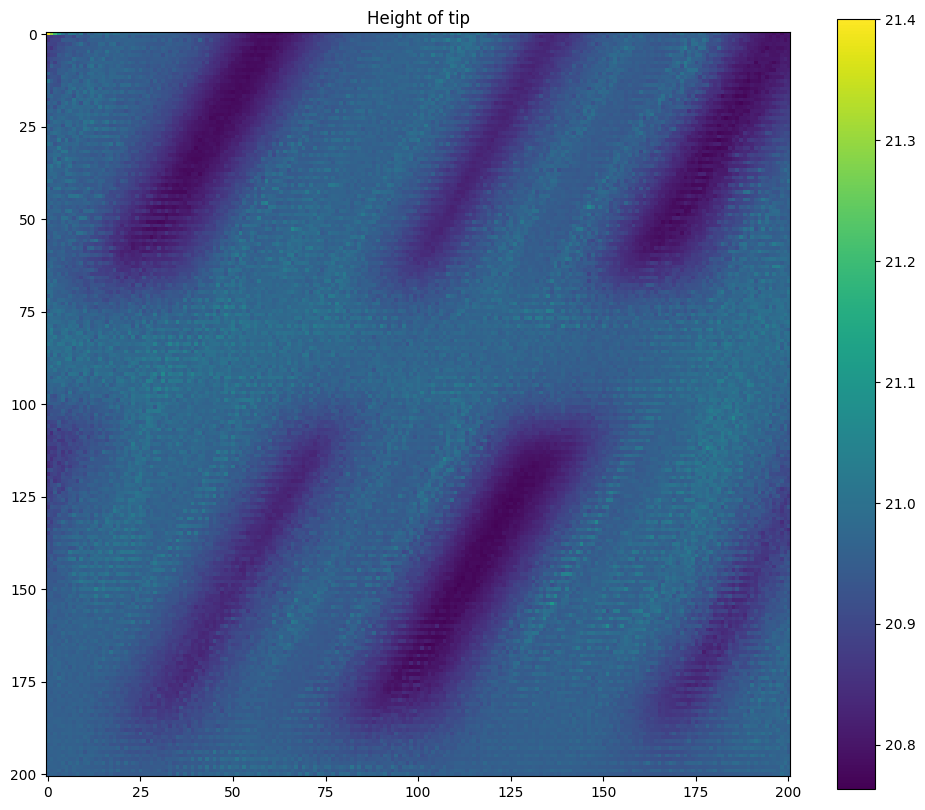

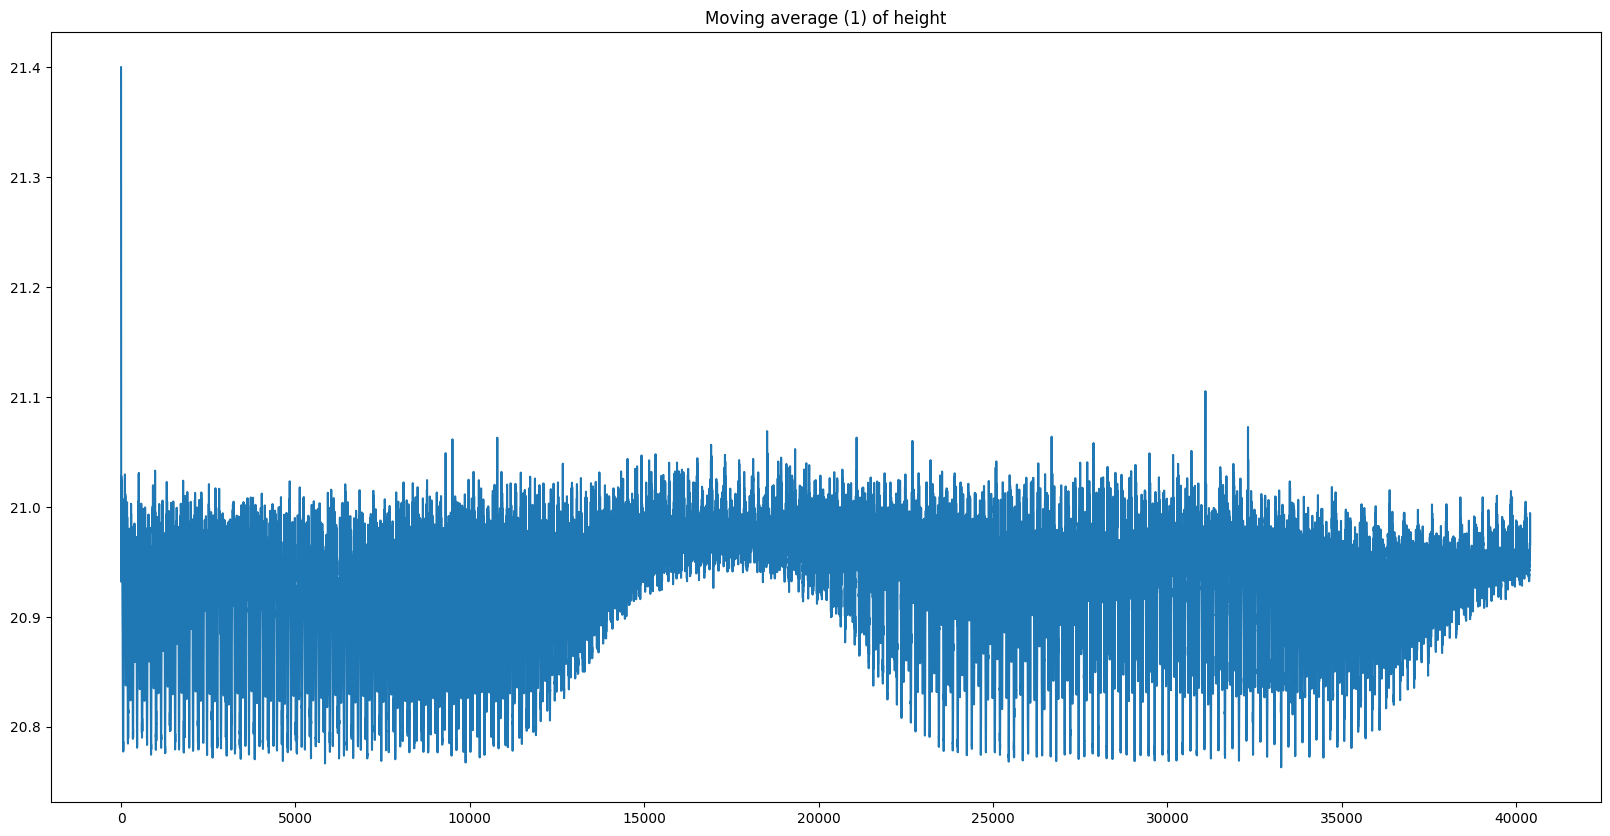

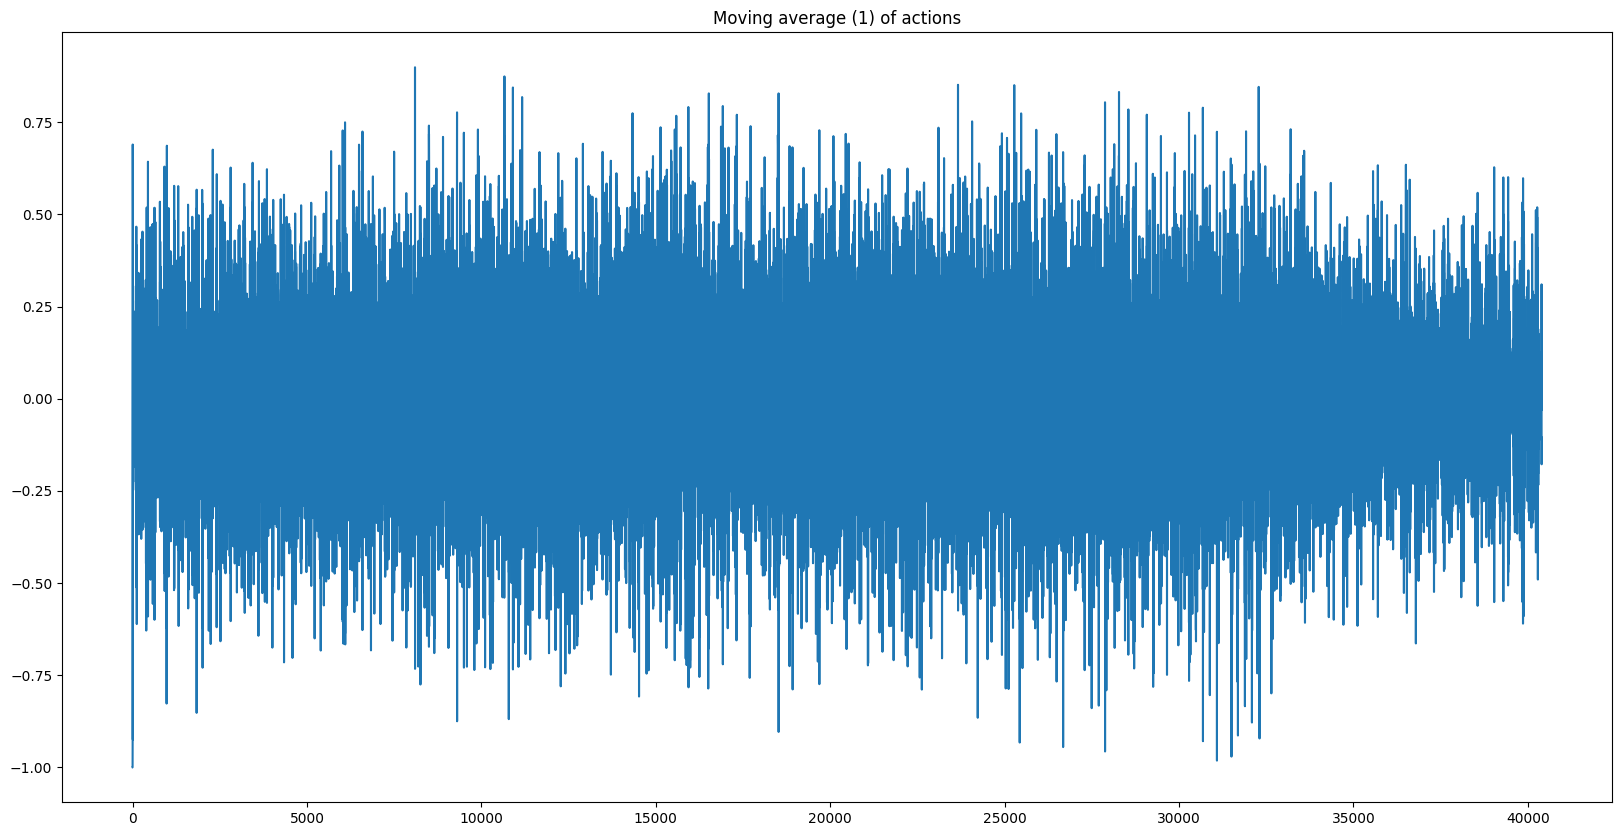

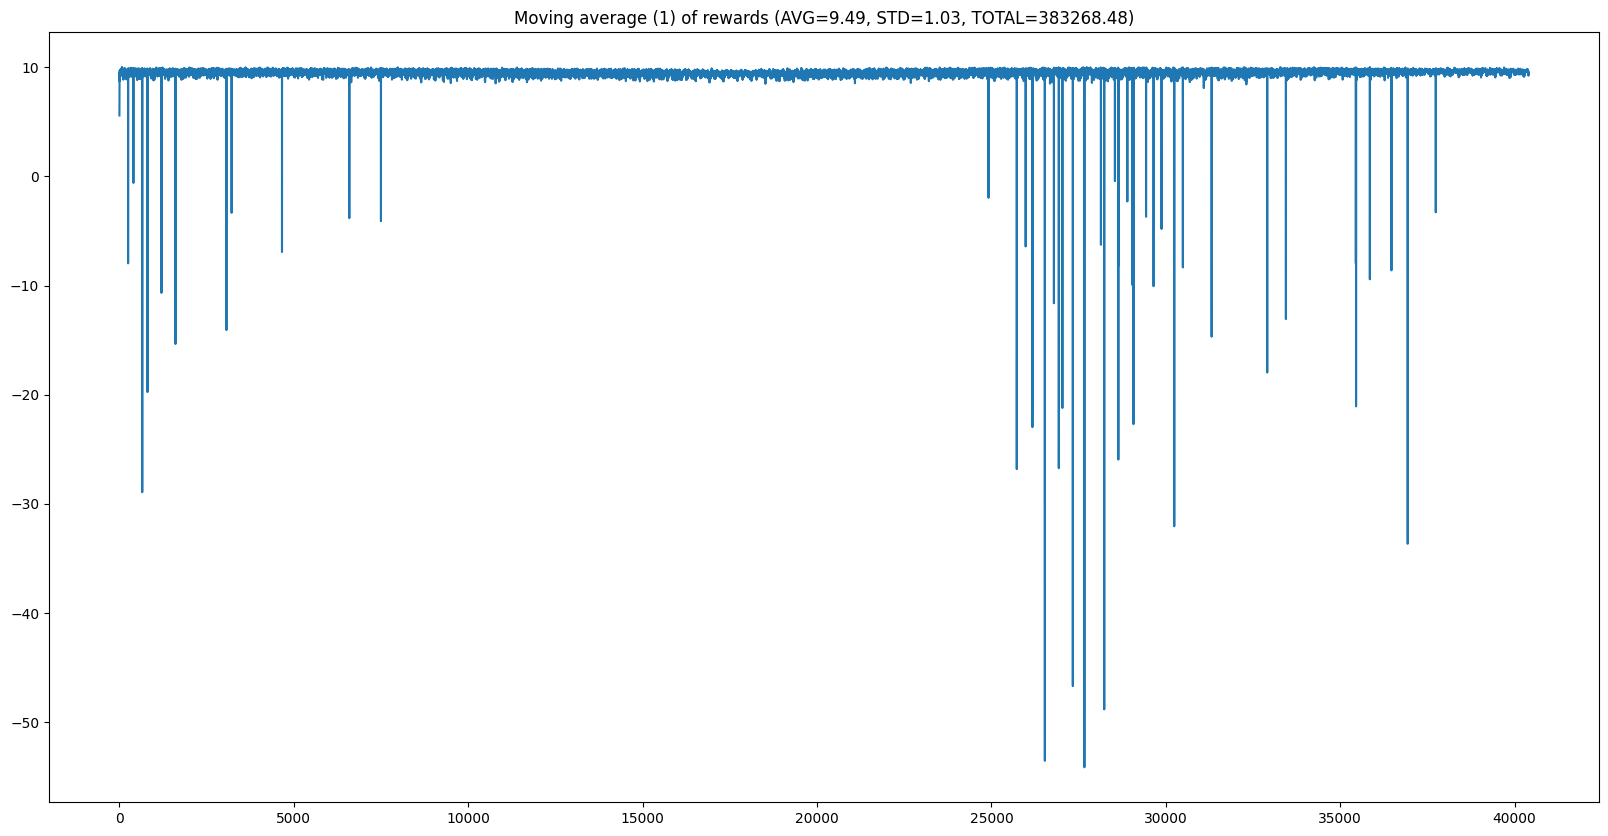

In [11]:
evaluate_run(episodes[max_id], ma_height_len=1, ma_action_len=1, ma_reward_len=1)

In [7]:
display(episodes[max_id]["rewards"])

array([5.57950136, 6.61735594, 7.64716103, ..., 9.22688393, 9.40297056,
       9.50752073], shape=(40400,))